# 01_Data_Cleaning

## Imports


In [49]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## Constants

Global constants and file paths are defined.

In [50]:
DATASET_PATH =  Path.cwd().parent / "data" / "raw" 
SAVE_PATH = Path.cwd().parent / "data" / "processed"

## Tools

Objects and tools that will be used repeatedly in the process are initialized.

In [51]:
le = LabelEncoder()

## Loading Data

The raw data is loaded from the disk. The use of a dedicated function allows for easier verification and logging of the entire loading process.

In [52]:
def load_data(file_path: Path, dataset_name: str) -> pd.DataFrame:
    """
    Load the dataset from the specified file path.

    Args:
        file_path (Path): The path to the dataset file.
        dataset_name (str): The name of the dataset to load.
    Returns:
        pd.DataFrame: The loaded dataset as a pandas DataFrame.
    """
    csv_path = file_path / dataset_name
    if not csv_path.exists():
        raise FileNotFoundError(f"The dataset file '{dataset_name}' does not exist at the specified path: {file_path}")
    return pd.read_csv(csv_path)


In [53]:
data = load_data(DATASET_PATH, "Housing.csv")

In [54]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Statistics

In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [56]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


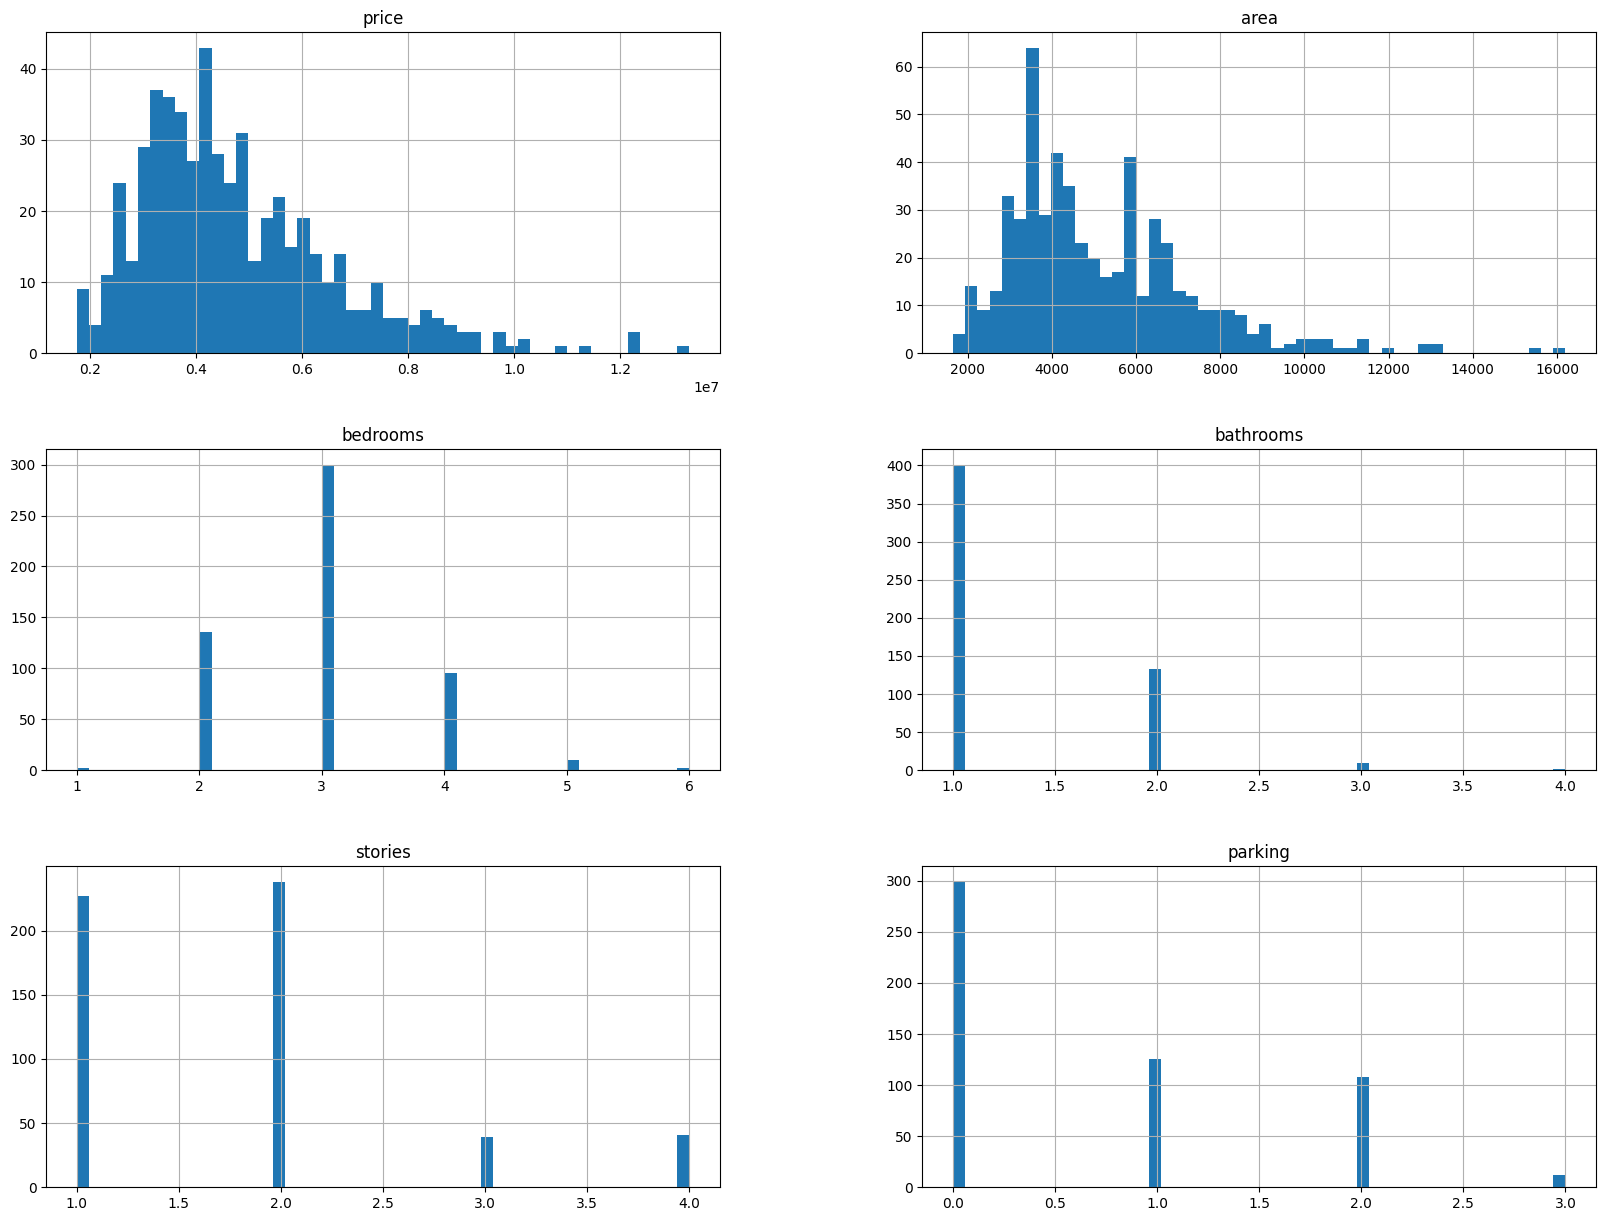

In [57]:
data.hist(bins=50, figsize=(20,15))
plt.show()

## Cleaning

The main stage of data transformation:
1. Empty rows/missing data (dropna) that could disrupt the models' performance are removed.
2. Text columns (categorical) are converted to numerical values, which is required by most machine learning algorithms.

In [58]:
data.dropna(inplace=True)

In [59]:
def convert_text_columns(data: pd.DataFrame, le: LabelEncoder) -> pd.DataFrame:
    """
    Convert text columns to numeric data type.
    Args:
        data (pd.DataFrame): The input DataFrame.
    
    Returns:
        pd.DataFrame: The DataFrame with converted columns.
    """
    text_columns = data.select_dtypes(include=['object', 'str']).columns.tolist()
    for col in text_columns:
        data[col] = le.fit_transform(data[col])
        mapping = dict(zip(le.classes_, range(len(le.classes_))))
        
        print(f"Mapping for column '{col}':")
        for text, number in mapping.items():
            print(f"  '{text}' -> {number}")
        print("-" * 30) 
            
    return data

In [60]:
data = convert_text_columns(data, le)

Mapping for column 'mainroad':
  'no' -> 0
  'yes' -> 1
------------------------------
Mapping for column 'guestroom':
  'no' -> 0
  'yes' -> 1
------------------------------
Mapping for column 'basement':
  'no' -> 0
  'yes' -> 1
------------------------------
Mapping for column 'hotwaterheating':
  'no' -> 0
  'yes' -> 1
------------------------------
Mapping for column 'airconditioning':
  'no' -> 0
  'yes' -> 1
------------------------------
Mapping for column 'prefarea':
  'no' -> 0
  'yes' -> 1
------------------------------
Mapping for column 'furnishingstatus':
  'furnished' -> 0
  'semi-furnished' -> 1
  'unfurnished' -> 2
------------------------------


In [61]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [62]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


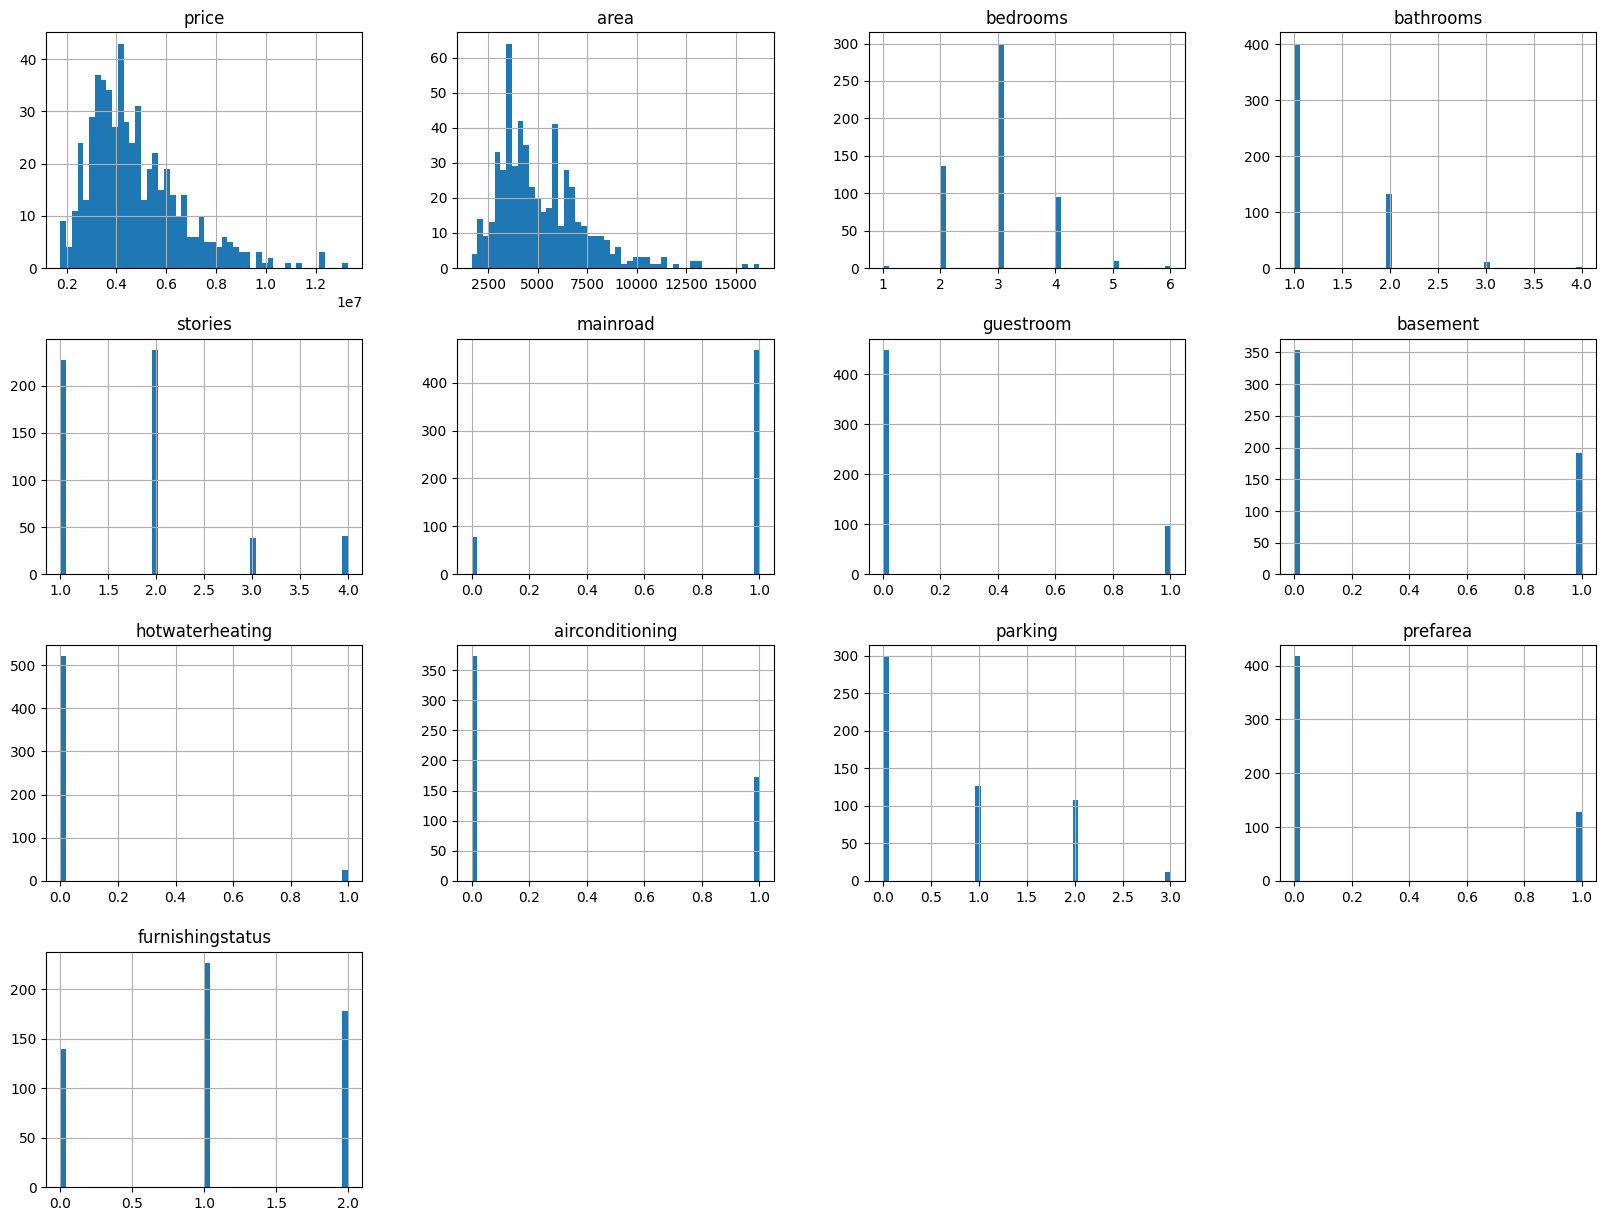

In [63]:
data.hist(bins=50, figsize=(20,15))
plt.show()

## Saving
Saving data frame to csv file

In [64]:
data.to_csv(SAVE_PATH / "Housing_cleaned.csv", index=False)